# AI-Powered Intelligent Hiring Assistant

## Phase 1: Data Preprocessing & Data Understanding

### Project Objective

###The goal of this notebook is to understand the resume dataset before building any Machine Learning model.

In this notebook, we will:

- Load the dataset
- Explore the dataset
- Check missing values
- Check duplicate records
- Understand different resume categories
- Analyze resume lengths
- Clean resume text
- Save the cleaned dataset for future phases

This notebook is the foundation of the complete AI Hiring Assistant project.


In [27]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [10]:
# Display all columns

pd.set_option("display.max_columns", None)

In [41]:
df= pd.read_json("resumes_dataset.jsonl", lines=True)

In [13]:
df.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas


In [15]:
df.sample(5)

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
549,REAL_0550,Data Science,Carla Browning,contact@email.com,100 10 555 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor 55...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor 55...,Computer Science degree,jessica claire 100 montgomery st 10th floor 55...,ResumeAtlas
2433,SYNTH_2434,Software Developer,John Davis,john.davis@yahoo.com,(996)632-5953x2787,"Johnsonfurt, NY",Experienced Software Developer with 4+ years b...,"MongoDB, REST API, AWS, React, Scrum, Git, Jav...",Software Engineer at Tesla (2022 - 2024): Deve...,Bachelor of Engineering in Computer Engineerin...,JOHN DAVIS\nEmail: john.davis@yahoo.com | Phon...,Synthetic
159,REAL_0160,Java Developer,Adrian Nguyen,contact@email.com,94105 555 4321000 1 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
879,REAL_0880,SQL Developer,Angela Johnson,contact@email.com,94105 555 4321000 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
2977,SYNTH_2978,Cybersecurity Analyst,Jeffrey Franklin,jeffrey.franklin@gmail.com,(555)280-9961x327,"West Ryan, MA",Dedicated Cybersecurity Analyst with 3+ years ...,"SIEM, Metasploit, Kali Linux, Network Security...",Senior Cybersecurity Analyst at GitHub (2021 -...,Bachelor of Engineering in Computer Engineerin...,═══ Jeffrey Franklin ═══\n📧 jeffrey.franklin@g...,Synthetic


In [16]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 3500
Number of Columns : 12


In [17]:
df.columns

Index(['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary',
       'Skills', 'Experience', 'Education', 'Text', 'Source'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ResumeID    3500 non-null   object
 1   Category    3500 non-null   object
 2   Name        3500 non-null   object
 3   Email       3500 non-null   object
 4   Phone       3500 non-null   object
 5   Location    3500 non-null   object
 6   Summary     3500 non-null   object
 7   Skills      3500 non-null   object
 8   Experience  3500 non-null   object
 9   Education   3500 non-null   object
 10  Text        3500 non-null   object
 11  Source      3500 non-null   object
dtypes: object(12)
memory usage: 328.3+ KB


In [19]:
missing_values = df.isnull().sum()

missing_values

,0
ResumeID,0
Category,0
Name,0
Email,0
Phone,0
Location,0
Summary,0
Skills,0
Experience,0
Education,0


In [20]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


In [21]:
df.describe(include="all")

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
count,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500
unique,3500,36,3410,1161,3279,1164,2226,919,3262,1160,3304,2
top,SYNTH_3500,Java Developer,Lisa Smith,contact@email.com,555-123-4567,"City, State",Experienced Software Developer with 9+ years b...,"Python, SQL, Git, Linux",ron phoenix blockchain developer 15491295157 d...,Computer Science degree,ron phoenix blockchain developer 15491295157 d...,ResumeAtlas
freq,1,200,4,2337,17,2337,20,2337,5,2337,4,2337


In [23]:
df["Category"].value_counts()

,count
Category,
Java Developer,200
Python Developer,200
Data Science,200
DevOps,180
SQL Developer,180
Database,150
Testing,150
Web Designing,150
React Developer,150


In [24]:
print("Total Categories :", df["Category"].nunique())

Total Categories : 36


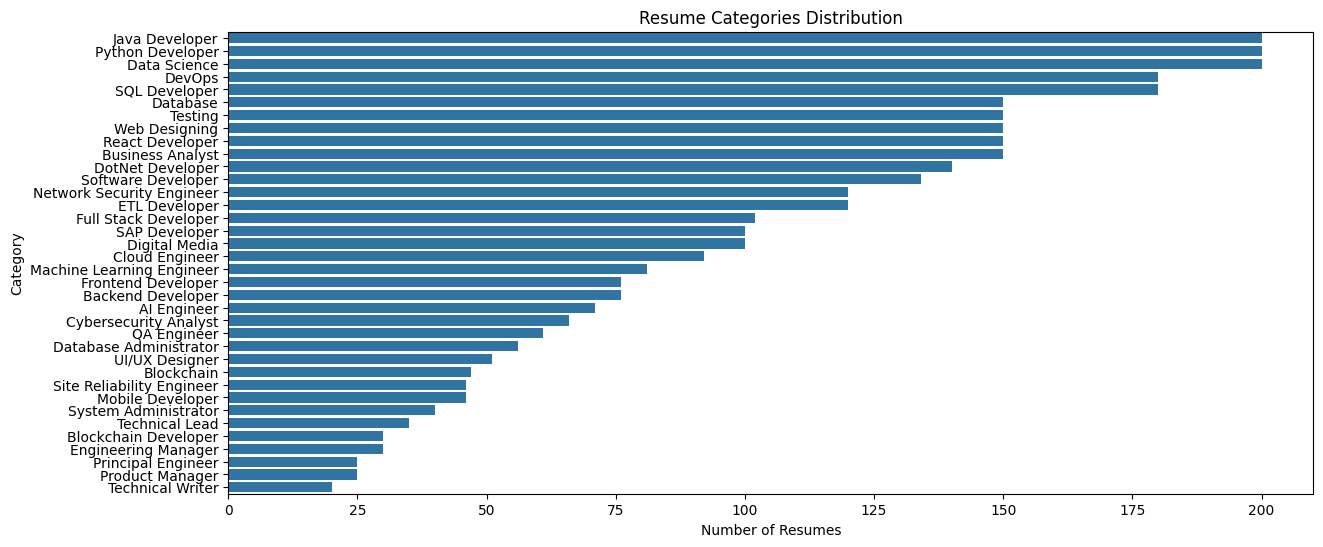

In [31]:

plt.figure(figsize=(14,6))

sns.countplot(
    y=df["Category"],
        order=df["Category"].value_counts().index)

plt.title("Resume Categories Distribution")

plt.xlabel("Number of Resumes")

plt.ylabel("Category")

plt.show()

In [32]:
import re

In [33]:
def clean_resume(text):

      text = re.sub(r"http\S+", " ", text)

      text = re.sub(r"www\S+", " ", text)

      text = re.sub(r"@\S+", " ", text)

      text = re.sub(r"[^A-Za-z ]", " ", text)

      text = re.sub(r"\s+", " ", text)

      return text.lower().strip()

In [43]:
df["Clean_Resume"] = df["Text"].fillna("").apply(clean_resume)

In [44]:
df[["Text","Clean_Resume"]].head()

,Text,Clean_Resume
0,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...
1,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer linkedincomi...
2,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire resumesampleexamplecom montgome...
3,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire resumesampleexamplecom montgome...
4,jessica claire 100 montgomery st 10th floor xx...,jessica claire montgomery st th floor xxx resu...


In [45]:
df.to_csv("clean_resume_dataset.csv", index=False)

print("Dataset Saved Successfully.")

Dataset Saved Successfully.
